##### Loading Libraries

In [1]:
# Machine Learning Project

In [2]:
# Importing the necessary libraries
import sys
sys.path.append(r"C:\Users\Akash Mittal\Documents\GitHub\ML-Kernel Based Classification\sources")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_process_scale import StandardScaling, TrainTestSplit, ZeroOneLoss
from perceptron_class import Perceptron
import SVM_pegasos
from Reg_log_class_2 import LogisticRegressionPegasos
from polynomial_features import PolynomialFeatureExpansion
from Kernel_Perceptron_F1 import KernelizedPerceptron
from Kernel_Pegasos_SVM_F2 import KernelizedPegasosSVM
from K_fold_CV import MyKFold # Custom Kfold CV
from GridSearch import cross_validate
from scipy.stats.mstats import winsorize


#### Data Synthesizing and Exploration

In [42]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=5)

y = 2*y-1

y

array([ 1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1, -1,  1,  1, -1,  1,  1,
       -1,  1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1,  1,
        1,  1, -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1, -1, -1, -1,  1,
        1, -1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1, -1,  1,
       -1, -1, -1,  1,  1, -1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1,
       -1, -1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1, -1,  1,  1])

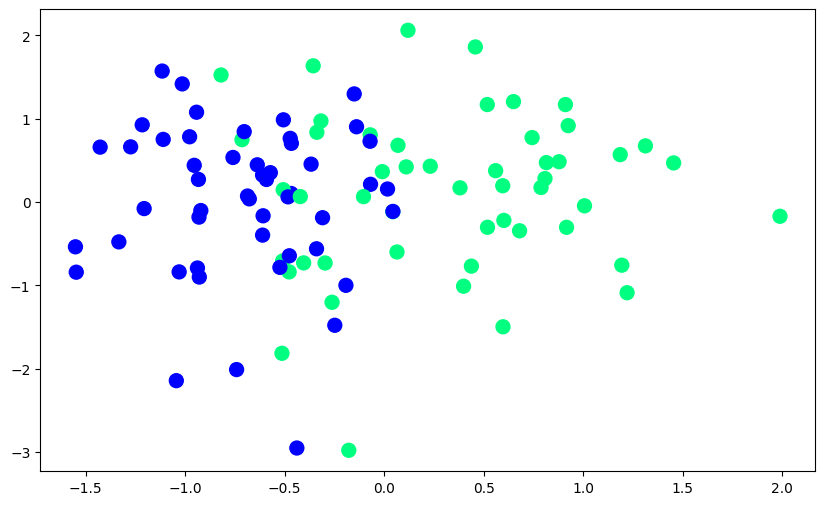

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)


### Sample Implementation

[1.57467018 0.12209448]
1.0


(-3.0, 2.0)

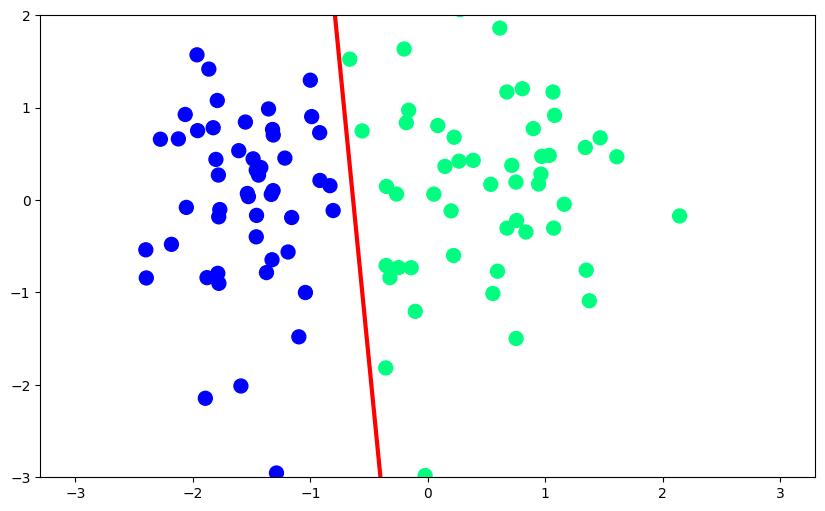

In [5]:
def perceptron_c(X,y):
    
    X = np.insert(X,0,1,axis=1) # Adding bias term to the input feature

    weights = np.ones(X.shape[1])
    # weights = np.zeros(X.shape[1]) 
    
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sign(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

def sign(z):
    return 1 if z>=0 else -1

intercept_,coef_ = perceptron_c(X,y)

print(coef_)
print(intercept_)

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])


x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [6]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = sign(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

def step(z):
    return 1 if z>0 else 0

m,b = perceptron(X,y)

%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)





<IPython.core.display.Javascript object>

## Perceptron Implementation

In [44]:
# bind  X and y to X_Reduced
X_reduced = pd.DataFrame(X, columns=['x1', 'x2']) 
X_reduced['y'] = y

In [45]:
X_reduced

,x1,x2,y
0,0.043255,-0.116976,1
1,-0.404812,-0.731152,1
2,-0.510482,-0.708106,1
3,-0.741719,-2.011992,-1
4,-0.356832,1.634932,1
...,...,...,...
95,-1.274181,0.661988,-1
96,-0.686852,0.071533,-1
97,-0.611201,0.323236,-1
98,0.680274,-0.345742,1


In [46]:
# Splitting the data
# instance of class for stratified splitting for balancing data
splitter = TrainTestSplit(test_size=0.40, random_state=42, stratify=True)
X_train, y_train, X_test, y_test = splitter.split(X_reduced)

#### Splitting the Data into training and test sets.

In [47]:
# Standardize features (fitting only on training data to avoid data leakage)
scaler = StandardScaling()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Converting to Arrays
X_train = X_train.to_numpy(dtype=np.float64)
X_test = X_test.to_numpy(dtype=np.float64)
y_train = y_train.to_numpy(dtype=np.float64)
y_test = y_test.to_numpy(dtype=np.float64)

In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60, 2)
(40, 2)
(60,)
(40,)


In [49]:
# Unique Labels in Training and Test Set
print(np.unique(y_train))
print(np.unique(y_test))


[-1.  1.]
[-1.  1.]


In [50]:
# loss_calculator = ZeroOneLoss()

### Perceptron Model

##### Parameter Grid

In [51]:
# Perceptron Parameter Grid
perceptron_param_grid = {
    'learning_rate': [0.01, 0.1, 1],
    'epochs': [5, 10, 15],
    'activation_func': ['sign'],
}

##### Model Training

In [52]:
# Model Cross-Validated
print("\nGrid Search for Perceptron...")
best_params_perceptron, best_score_perceptron, best_cv_perceptron, history_perceptron = cross_validate(
    model_class=Perceptron,
    param_grid=perceptron_param_grid,
    X=X_train,
    y=y_train,
    k=5,
    shuffle=True,
    random_state=42,
    verbose=True
)


Grid Search for Perceptron...
Testing Hyperparameters: {'learning_rate': 0.01, 'epochs': 5, 'activation_func': 'sign'}
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Mean Score: 0.6833333333, Std Dev: 0.1929306150, CV: 0.2823374854
Testing Hyperparameters: {'learning_rate': 0.01, 'epochs': 10, 'activation_func': 'sign'}
Training with 10 epochs
Training with 10 epochs
Training with 10 epochs
Training with 10 epochs
Training with 10 epochs
Training with 10 epochs
Train

##### Best Model and Test Accuracy

In [53]:
perceptron_best = Perceptron(**best_params_perceptron)
weights_p, bias_p, boundary_lines = perceptron_best.fit(X_train, y_train)
y_pred_best = perceptron_best.predict(X_test)
accuracy_best_p = perceptron_best.accuracy(X_test, y_test)
loss_best_p = 1 - accuracy_best_p

print(f"Test Accuracy for Perceptron with Best Hyperparameters: {accuracy_best_p:.4f}")
print(f"Loss for Perceptron with Best Hyperparameters: {loss_best_p:.4f}")

Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Training with 5 epochs
Test Accuracy for Perceptron with Best Hyperparameters: 0.8000
Loss for Perceptron with Best Hyperparameters: 0.2000


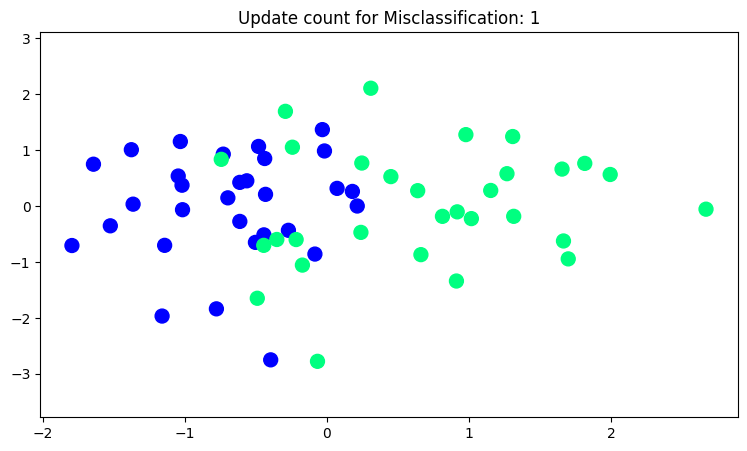

In [57]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

x_vals = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100) # linearly spaced numerals for first column of X_train
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', s=100)  # scatter plot of the 2D data

line, = ax.plot([], [], 'r-', linewidth=2) # empty line

plt.ylim(X_train[:, 1].min()-1, X_train[:, 1].max()+1) # y axis limits

def update(i):
    m, b = boundary_lines[i]
    line.set_data(x_vals, m * x_vals + b)
    ax.set_title(f"Update count for Misclassification: {i + 1}")
    return line,

anim = FuncAnimation(fig, update, frames=len(boundary_lines), interval=100)

In [58]:
anim.save("best_perceptron_training_4.gif", writer="pillow")

In [24]:
type(boundary_lines)

list

In [59]:
len(boundary_lines)

78

In [16]:
X.shape[0]

100

##### Plots

In [33]:
%matplotlib inline


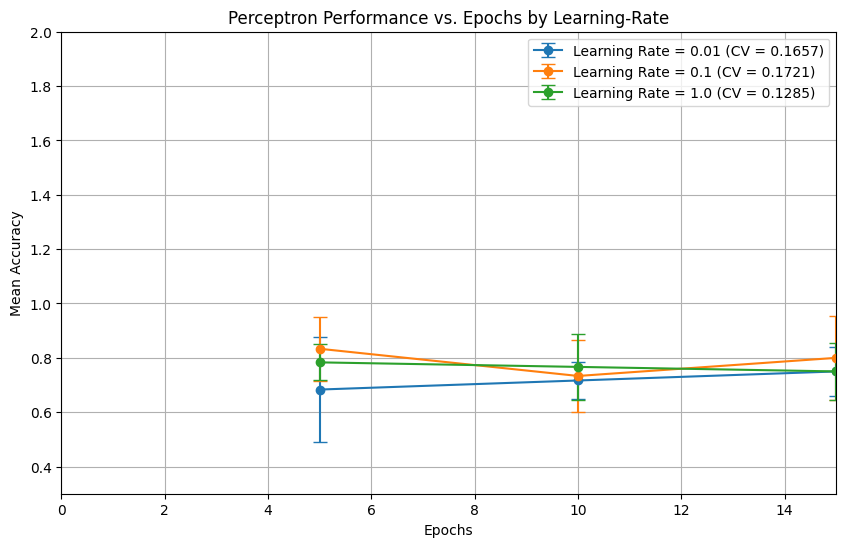

In [60]:
# Mean Accuracy by Epochs with Standard deviation

# Convert history_perceptron to a DataFrame
history_perceptron = pd.DataFrame(history_perceptron)

# Extract 'learning_rate' and 'epochs' from the 'params' column
history_perceptron['learning_rate'] = history_perceptron['params'].apply(lambda x: x['learning_rate'])
history_perceptron['epochs'] = history_perceptron['params'].apply(lambda x: x['epochs'])

# Plot
plt.figure(figsize=(10, 6))
for lr in history_perceptron['learning_rate'].unique():
    subset = history_perceptron[history_perceptron['learning_rate'] == lr].sort_values(by='epochs')
    plt.errorbar(
        subset['epochs'],
        subset['mean_score'],
        yerr=subset['std_dev'],
        marker='o',
        label=f'Learning Rate = {lr} (CV = {subset["cv"].mean():.4f})',
        capsize=5
    )

plt.xlim(0, 15)  # Set x-axis range (0 to 550)
plt.ylim(0.30, 2)  # Set y-axis range (0.55 to 0.70)

plt.xlabel('Epochs')
plt.ylabel('Mean Accuracy')
plt.title('Perceptron Performance vs. Epochs by Learning-Rate')
plt.legend()
plt.grid(True)
plt.show()

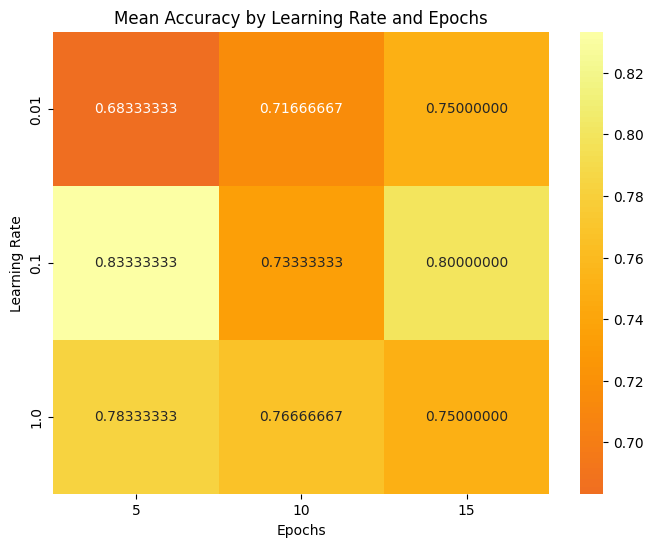

In [61]:
# Convert history_perceptron to a DataFrame for easier plotting
history_df = pd.DataFrame(history_perceptron)

# Extract 'learning_rate' and 'epochs' from the 'params' column
history_df['learning_rate'] = history_df['params'].apply(lambda x: x['learning_rate'])
history_df['epochs'] = history_df['params'].apply(lambda x: x['epochs'])

# Create a pivot table for the heatmap
heatmap_data = history_df.pivot_table(
    index='learning_rate',
    columns='epochs',
    values='mean_score'
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".8f", cmap='inferno', center=0.6)
plt.title('Mean Accuracy by Learning Rate and Epochs')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.show()

In [62]:
print(heatmap_data)

epochs               5         10    15
learning_rate                          
0.01           0.683333  0.716667  0.75
0.10           0.833333  0.733333  0.80
1.00           0.783333  0.766667  0.75


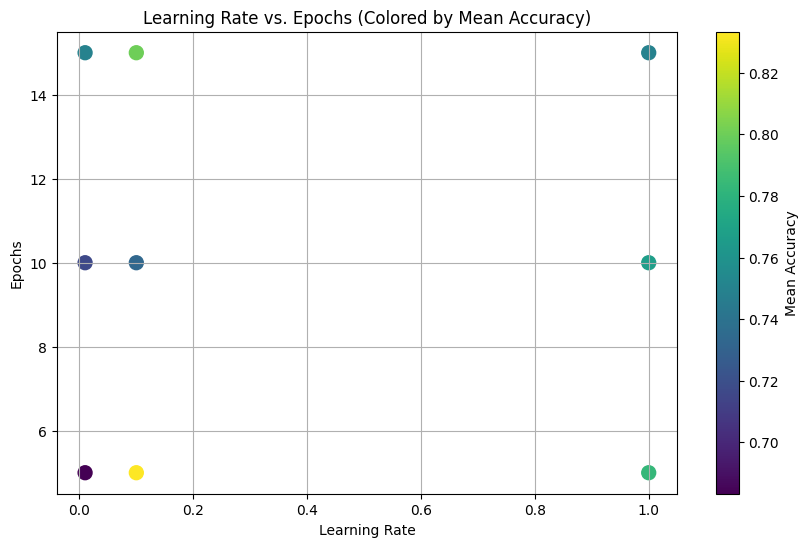

In [63]:
# Learning Rate & Epochs with Mean Accuracy

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    history_df['learning_rate'],
    history_df['epochs'],
    c=history_df['mean_score'],
    cmap='viridis',
    s=100  # Size of points
)
plt.colorbar(scatter, label='Mean Accuracy')
plt.xlabel('Learning Rate')
plt.ylabel('Epochs')
plt.title('Learning Rate vs. Epochs (Colored by Mean Accuracy)')
plt.grid(True)
plt.show()

### End of Perceptron